In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp
from src.funciones import *

In [2]:
# Abrir archivo raw_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78988 entries, 0 to 78987
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha               78988 non-null  datetime64[ns]
 1   Close               78988 non-null  float64       
 2   Ticker              78988 non-null  object        
 3   Beta                71247 non-null  float64       
 4   MarketCap           78708 non-null  float64       
 5   EnterpriseValue     78708 non-null  float64       
 6   PE_Trailing         78537 non-null  float64       
 7   EnterpriseToEbitda  78708 non-null  float64       
 8   PriceToBook         78498 non-null  float64       
 9   operatingMargins    78949 non-null  float64       
 10  profitMargins       78778 non-null  float64       
 11  returnOnEquity      78568 non-null  float64       
 12  ReturnOnAssets      78739 non-null  float64       
 13  debtToEquity        78739 non-null  float64   

In [3]:
columnas_a_eliminar = ['Close']
df.drop(columnas_a_eliminar, axis=1, inplace=True)

# Formatear market cap y EnterpriseValue en billions
df["MarketCap"] = df["MarketCap"] / 10**9
df["EnterpriseValue"] = df["EnterpriseValue"] / 10**9

In [4]:
# Formatear market cap y EnterpriseValue en billions
df["MarketCap"] = df["MarketCap"] / 10**9
df["EnterpriseValue"] = df["EnterpriseValue"] / 10**9

# Variables continuas

In [5]:
# Distribucion de variables continuas
df.describe().round(2).T

,count,mean,min,25%,50%,75%,max,std
Fecha,78988,2024-10-08 06:01:39.539170560,2022-06-06 00:00:00,2023-12-11 00:00:00,2024-10-14 00:00:00,2025-08-11 00:00:00,2026-06-08 00:00:00,NaN
Beta,71247.0,0.91,-1.49,0.49,0.86,1.24,7.73,0.6
MarketCap,78708.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EnterpriseValue,78708.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PE_Trailing,78537.0,-14.82,-105950.34,15.46,24.11,35.83,6121.58,1953.8
EnterpriseToEbitda,78708.0,22.41,-1843.02,11.02,15.71,21.82,3287.8,89.12
PriceToBook,78498.0,7.04,-1168.96,1.86,3.71,8.04,1430.58,53.43
operatingMargins,78949.0,0.19,-1.6,0.11,0.18,0.26,0.93,0.15
profitMargins,78778.0,0.13,-1.72,0.07,0.12,0.2,1.04,0.16
returnOnEquity,78568.0,0.22,-36.77,0.08,0.16,0.31,39.48,2.27


In [6]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

Beta                   1.150939
MarketCap              8.305831
EnterpriseValue        8.162476
PE_Trailing          -39.258081
EnterpriseToEbitda    13.933712
PriceToBook            7.732001
operatingMargins      -0.476065
profitMargins         -1.956532
returnOnEquity         0.903383
ReturnOnAssets         0.714622
debtToEquity          -3.790287
currentRatio           6.760126
dtype: float64

Cont


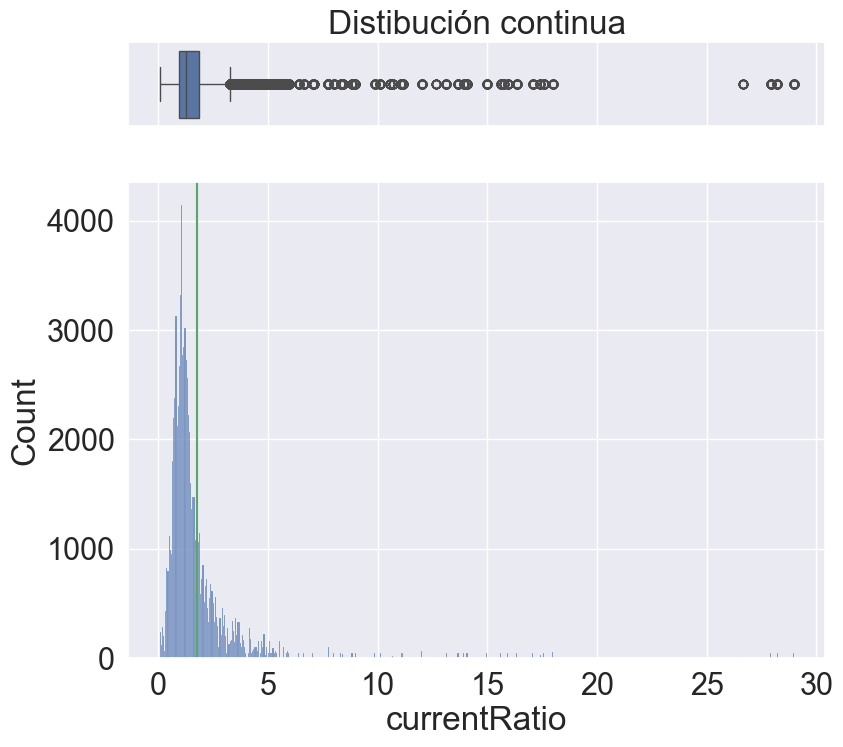

In [7]:
# Graficar
columna_a_graficar = 'currentRatio' # indicar columna para el grafico
plot(df[columna_a_graficar])

In [8]:
# Transformacion yeo-johnson
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['PriceToBook', 'returnOnEquity', 'PE_Trailing', 'EnterpriseToEbitda']
for columna in columnas_a_transformar:
    df[f'{columna}_Transformed'] = pt.fit_transform(df[[columna]])
    # Elimino la columna sin transformar
    df.drop(columna, axis=1, inplace=True)

In [9]:
# Transformaciones logarítmicas
columnas_a_transformar = ['MarketCap', 'EnterpriseValue', 'debtToEquity', 'currentRatio']
for columna in columnas_a_transformar:
    df[f'{columna}_log'] = np.log1p(df[columna])
    df.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df.select_dtypes(include="number").skew()

c:\Users\sebas\anaconda3\envs\ucm-dev\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Beta                              1.150939
operatingMargins                 -0.476065
profitMargins                    -1.956532
ReturnOnAssets                    0.714622
PriceToBook_Transformed           4.234795
returnOnEquity_Transformed       -0.178984
PE_Trailing_Transformed           9.987781
EnterpriseToEbitda_Transformed    9.382365
MarketCap_log                     8.305825
EnterpriseValue_log               8.162470
debtToEquity_log                  2.405524
currentRatio_log                  1.871222
dtype: float64

## Gestion de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [10]:
# Outliers
df_cont = df.select_dtypes(include="number")
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Beta
operatingMargins
profitMargins
ReturnOnAssets
PriceToBook_Transformed
returnOnEquity_Transformed
PE_Trailing_Transformed
EnterpriseToEbitda_Transformed
MarketCap_log
EnterpriseValue_log
debtToEquity_log
currentRatio_log


In [11]:
# Coeficientes de asimetria actualizados luego de winsorizar
df_winsor.skew()

Beta                              0.750107
operatingMargins                  0.520813
profitMargins                     0.151778
ReturnOnAssets                    0.574936
PriceToBook_Transformed           0.223956
returnOnEquity_Transformed        0.936024
PE_Trailing_Transformed           0.927384
EnterpriseToEbitda_Transformed    0.949179
MarketCap_log                     0.000000
EnterpriseValue_log               0.000000
debtToEquity_log                  1.490906
currentRatio_log                  1.219656
dtype: float64

Cont


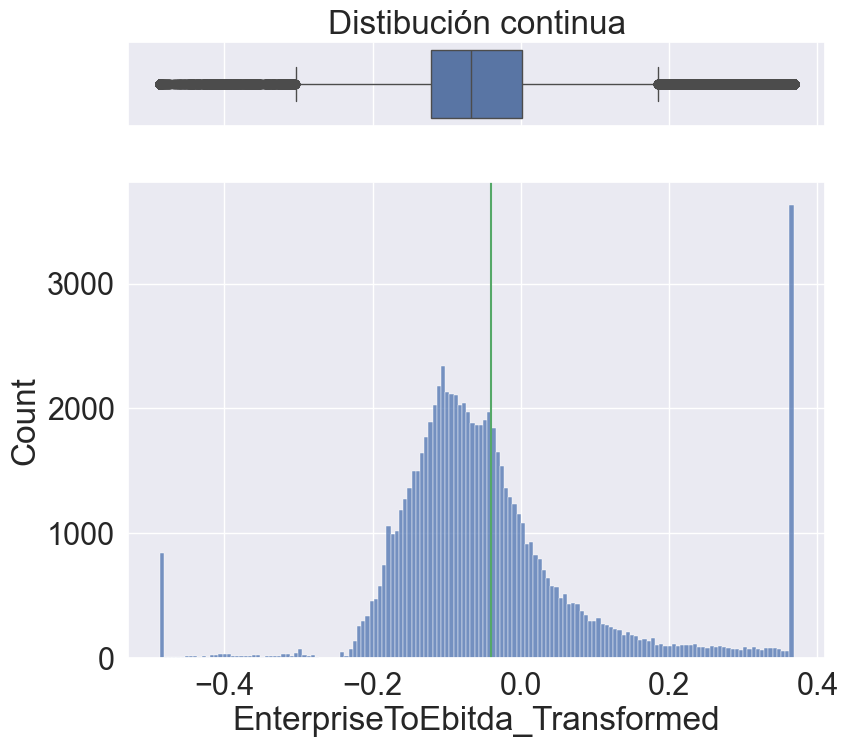

In [12]:
# Visualizar cambios
columna_a_graficar = 'EnterpriseToEbitda_Transformed' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [13]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Beta,71247.0,9.043477e-01,5.870140e-01,-1.487400e+00,4.896000e-01,8.625000e-01,1.241400e+00,3.503800e+00
operatingMargins,78949.0,1.916694e-01,1.407006e-01,-3.598000e-01,1.065000e-01,1.781000e-01,2.611000e-01,7.419000e-01
profitMargins,78778.0,1.358582e-01,1.301090e-01,-3.532000e-01,6.690000e-02,1.215000e-01,1.971000e-01,6.031000e-01
ReturnOnAssets,78739.0,7.941346e-02,7.724753e-02,-2.277000e-01,3.290000e-02,6.370000e-02,1.176000e-01,3.887000e-01
PriceToBook_Transformed,78498.0,-1.710884e-02,1.644932e-01,-4.329986e-01,-8.459989e-02,-4.960340e-02,3.146094e-02,3.798615e-01
returnOnEquity_Transformed,78568.0,-8.185146e-03,4.670536e-01,-3.149529e+00,-5.780092e-02,-2.156078e-02,4.320531e-02,3.264760e+00
PE_Trailing_Transformed,78537.0,-5.129969e-02,6.221517e-02,-2.386269e-01,-8.509302e-02,-6.421927e-02,-3.392923e-02,1.195829e-01
EnterpriseToEbitda_Transformed,78708.0,-4.085914e-02,1.432816e-01,-4.875101e-01,-1.209248e-01,-6.773043e-02,1.262833e-03,3.678697e-01
MarketCap_log,78708.0,6.181212e-08,6.587839e-08,6.997463e-10,1.810468e-08,3.479989e-08,7.562426e-08,2.482535e-07
EnterpriseValue_log,78708.0,7.446034e-08,7.668791e-08,2.611904e-09,2.261539e-08,4.332615e-08,8.939324e-08,2.897625e-07


# Variables Categoricas

In [14]:
df_non_numeric = df.select_dtypes(exclude='number')

In [15]:
# Valores unicos
df_non_numeric.nunique()

Fecha          210
Ticker         455
Sector          11
SubIndustry    119
DateAdded      338
dtype: int64

In [16]:
# Convertir Sector y SubIndustrya category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')
df_non_numeric['SubIndustry'] = df_non_numeric['SubIndustry'].astype('category')

# Valores unicos en Sector
df_non_numeric['Sector'].value_counts()

Sector
Industrials               13703
Information Technology    12368
Health Care                9869
Consumer Discretionary     8293
Consumer Staples           6458
Financials                 5543
Real Estate                5301
Utilities                  5143
Materials                  4486
Communication Services     4067
Energy                     3757
Name: count, dtype: int64

In [17]:
# Valores unicos en SubIndustry
df_non_numeric['SubIndustry'].value_counts()

SubIndustry
Health Care Equipment                           2973
Electric Utilities                              2565
Application Software                            2475
Semiconductors                                  2439
Industrial Machinery & Supplies & Components    2430
                                                ... 
Food Retail                                      167
Homefurnishing Retail                            167
Footwear                                         158
Heavy Electrical Equipment                       116
Health Care Technology                           116
Name: count, Length: 119, dtype: int64

In [19]:
df_non_numeric[df_non_numeric['Sector'].isnull()]

,Fecha,Ticker,Sector,SubIndustry,DateAdded


In [20]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_non_numeric['DateAdded'] = pd.to_datetime(df_non_numeric['DateAdded'], errors='coerce')
df_non_numeric['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_non_numeric['DateAdded']).dt.days / 365.25), 0)
df_non_numeric.drop('DateAdded', axis=1, inplace=True)

In [21]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_non_numeric, df_winsor], axis=1)
df_combined.head()

,Fecha,Ticker,Sector,SubIndustry,YearsSinceAdded,Beta,operatingMargins,profitMargins,ReturnOnAssets,PriceToBook_Transformed,returnOnEquity_Transformed,PE_Trailing_Transformed,EnterpriseToEbitda_Transformed,MarketCap_log,EnterpriseValue_log,debtToEquity_log,currentRatio_log
0,2023-01-02,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.032949,0.012443,-0.037828,0.020323,4.308682e-08,4.480282e-08,0.420025,1.108596
1,2023-01-09,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.042417,0.012443,-0.032106,0.036232,4.578576e-08,4.750176e-08,0.420025,1.108596
2,2023-01-16,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.041394,0.012443,-0.032727,0.034513,4.549399e-08,4.720999e-08,0.420025,1.108596
3,2023-01-23,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.041157,0.012443,-0.032870,0.034118,4.542687e-08,4.714287e-08,0.420025,1.108596
4,2023-01-30,A,Health Care,Life Sciences Tools & Services,26.0,NaN,0.2363,0.1831,0.1191,0.039991,0.012443,-0.033578,0.032158,4.509424e-08,4.681024e-08,0.420025,1.108596


# Missings

In [22]:
df_combined.isnull().sum()

Fecha                                0
Ticker                               0
Sector                               0
SubIndustry                          0
YearsSinceAdded                      0
Beta                              7741
operatingMargins                    39
profitMargins                      210
ReturnOnAssets                     249
PriceToBook_Transformed            490
returnOnEquity_Transformed         420
PE_Trailing_Transformed            451
EnterpriseToEbitda_Transformed     280
MarketCap_log                      280
EnterpriseValue_log                280
debtToEquity_log                  5752
currentRatio_log                    78
dtype: int64

In [25]:
# Resto de las continuas: imputar multivariable con IterativeImputer
df_cont = df_combined.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [26]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78988 entries, 0 to 78987
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   YearsSinceAdded                 78988 non-null  float64
 1   Beta                            78988 non-null  float64
 2   operatingMargins                78988 non-null  float64
 3   profitMargins                   78988 non-null  float64
 4   ReturnOnAssets                  78988 non-null  float64
 5   PriceToBook_Transformed         78988 non-null  float64
 6   returnOnEquity_Transformed      78988 non-null  float64
 7   PE_Trailing_Transformed         78988 non-null  float64
 8   EnterpriseToEbitda_Transformed  78988 non-null  float64
 9   MarketCap_log                   78988 non-null  float64
 10  EnterpriseValue_log             78988 non-null  float64
 11  debtToEquity_log                78988 non-null  float64
 12  currentRatio_log                

In [27]:
df_final = pd.concat([df_imputed, df_combined.select_dtypes(exclude='number')], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78988 entries, 0 to 78987
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   YearsSinceAdded                 78988 non-null  float64       
 1   Beta                            78988 non-null  float64       
 2   operatingMargins                78988 non-null  float64       
 3   profitMargins                   78988 non-null  float64       
 4   ReturnOnAssets                  78988 non-null  float64       
 5   PriceToBook_Transformed         78988 non-null  float64       
 6   returnOnEquity_Transformed      78988 non-null  float64       
 7   PE_Trailing_Transformed         78988 non-null  float64       
 8   EnterpriseToEbitda_Transformed  78988 non-null  float64       
 9   MarketCap_log                   78988 non-null  float64       
 10  EnterpriseValue_log             78988 non-null  float64       
 11  de

In [28]:
df_final.select_dtypes(include='number').skew()

YearsSinceAdded                   1.038484
Beta                              0.774130
operatingMargins                  0.520960
profitMargins                     0.147703
ReturnOnAssets                    0.569937
PriceToBook_Transformed           0.221662
returnOnEquity_Transformed        0.939084
PE_Trailing_Transformed           0.922790
EnterpriseToEbitda_Transformed    0.952636
MarketCap_log                     0.000000
EnterpriseValue_log               0.000000
debtToEquity_log                  0.121644
currentRatio_log                  1.220671
dtype: float64

In [29]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")